# Example 12: Local Regression

## Local linear regression

Local linear regression, a variant of non-parametric regression, is a method used to fit data points by applying linear regression in a local neighborhood of each point. 

### How It Works

1. **Weighted Fit**: At each point of interest, the algorithm computes a weighted linear regression, considering only the data points in the vicinity of that point.
2. **Kernel Function**: Weights are assigned using a kernel function, with the most common choice being the Gaussian kernel. The bandwidth of the kernel (a tuning parameter) determines the size of the neighborhood.
3. **Edge Effects**: Local linear regression can adapt to changes in behavior near the boundaries of the data, a situation where many global models struggle.

In [1]:
# Standard imports and abbreviations
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Tools and metrics for regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Needed to suppress warnings with polynomial fit
import warnings

# Needed to provide type hints for functions passed as arguments
from typing import Callable

The dataset in this example has a ground truth of $Y = \sin(X) + \epsilon$. We also generate variables for plotting the ground truth and for creating a validation set (for picking the hyperparameter $\lambda$ and a testing set for evaluating the model that is selected.  

We break down the dataset to be 60% training, 20% validation, and 20% testing. 

In [2]:
# Generate synthetic data
np.random.seed(13)
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100)  # Generate noisy data

# Used for plotting results and ground truth
X_range = np.linspace(0, 10, 500)
y_truth = np.sin(X_range)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=12)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=12)

# For fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

Now we define the kernel function, which will depend on the choice $D(t)$. Remember that this function is $$K(x_0, x) = D\left(\frac{\left|x - x_0\right|}{\lambda} \right).$$ 

For the fully general case (equation 6.5 in the textbook), we use $h_\lambda(x_0)$, which allow for adjustable windows depending on the point $x_0$ from which we are estimating.

In [3]:
def kernel(x0:float, X:np.ndarray, 
           lam:float, D:Callable) -> np.ndarray:
    """
    Returns 1D numpy array of kernel values of X centered at x0
    """

    kernel_values = [D(np.abs(xi - x0) / lam) for xi in X]

    return kernel_values

While there are many possible $D(t)$ functions, here we offer three to use for these problems. 

The quadtradic is a piecewise function where the nonzero portion is degree 2: 
$$D(t) = \begin{cases} \frac{3}{4}\left(1-t^2\right) &\text{if} |t| \leq 1 \\ 0 & \text{otherwise}\end{cases}.$$

The tricube is a piecewise function where the nonzero portion is degree 3: 
$$D(t) = \begin{cases} \left(1-|t|^3\right)^3 &\text{if} |t| \leq 1 \\ 0 & \text{otherwise}\end{cases}.$$

Finally, we have the Gaussian function, which has infinite support (there is no nonzero portion). It is setup to have mean 0 and standard deviation 1. 

One exercise I recommend is to integrate all three choices of $D$. Similarly, check the the first and second derivatives of $\frac{3}{4}\left(1-t^2\right)$ and $\left(1-|t|^3\right)^3$ at the values $1$ and $-1$. 

Note that one could use the validation set to select the best choice of $D$. We don't do that here, however, but it is also a good exercise to try to implement this on your own. 

In [4]:
def quadratic(t:float) -> float:
    """
    Returns value of quadratic density function at t
    """
    
    if np.abs(t) <= 1:
        return 0.75*(1-t**2)
    else:
        return 0

def tricube(t:float) -> float:
    """
    Returns value of tri-cube density function at t
    """
    
    if np.abs(t) <= 1:
        return (1-np.abs(t)**3)**3
    else:
        return 0
 
def gaussian(t:float, mu:float=0, 
             sigma:float=1) -> float:
    """
    Returns value of Gaussian density function at t, with mean 0 and standard deviation 1
    """
    
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-((t - mu) ** 2 / (2 * sigma ** 2)))

The implementation of local linear regression pointwise is performed below. Notice that we first calculate the weights of the linear regression model at each point using $K_\lambda(x_0, x)$ and then perform linear regression at that point. The method of linear regression is gotten from statsmodels, but the one from Sci-Kit Learn would also work here. 

In [5]:
def local_regression(x0:float, X:np.ndarray, y:np.ndarray, 
                     lam:float, K:Callable, D:Callable) -> float:
    """
    Computes estimate of y0 using local linear regression at point x0 with training sets X and y
    """
    
    # Calculate the weights using the kernel
    weights = K(x0, X, lam, D)
    
    # Fit a weighted linear regression model
    model = sm.WLS(y, sm.add_constant(X), weights=weights)
    results = model.fit()
    
    # Predict the value at x0
    y_pred = results.predict([1, x0])  # Add a constant term for the intercept
    
    return y_pred[0] # y_pred is a numpy array with one element

This next cell of code is an opportunity to tinker with the model visually. You can adjust the values of $\lambda$ and $D$, then see the impact visually. We do not provide any testing metrics; however, if one were to include those here, it would be best to use the validation set since the choices of $\lambda$ and $D$ are hyperparameters of our model and this tinkering would inform those choices. 

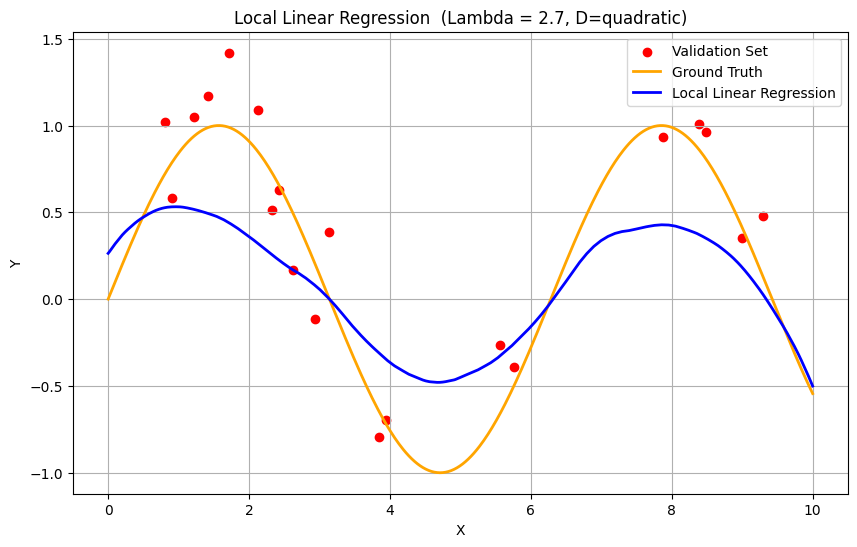

In [6]:
# testing fits with different lambda values and D(t)
lam = 2.7
D = quadratic

# Iterate through X_range and calculate y_pred using local regression
y_pred_plot = [local_regression(x0, X_train, y_train, lam, kernel, D) for x0 in X_range]

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_val, y_val, color='red', label='Validation Set')
plt.plot(X_range, y_truth, label=f'Ground Truth', color='orange', linewidth=2)
plt.plot(X_range, y_pred_plot, color='blue', lw=2, label=f'Local Linear Regression')
plt.title(f'Local Linear Regression  (Lambda = {lam}, D={D.__name__})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

Now let's move on to selecting the value of $\lambda$. For simplicity, we only use the validation set for this choice and stick with the choice of $D$ within the previous cell; however, you could adjust this code to also select $D$ with $\lambda$. You can see this done with local polynomial regression, which requires a choice of $\lambda$ and a choice of maximum polynomial degree. 

In [7]:
lam_values = np.arange(0.1, 2.6, 0.1) # We choose to check lambda values from 0.1 to 2.5

Here, we cycle through all values of $\lambda$ and select the value of $\lambda$ corresponding to the lowest value for mean squared error with the validation set. Notice that we only train with the training set. 

In [8]:
validation_mse = [] # selection will be made based on validation MSE
validation_r2 = [] # validation R^2 is also looked at, but not directly used. 

for lam in lam_values:
    
    # Predict on the validation set
    y_pred_val = [local_regression(x0, X_train, y_train, lam, kernel, D) for x0 in X_val]
    
    # Calculate Mean Squared Error (MSE) on the validation set
    mse = mean_squared_error(y_val, y_pred_val)
    
    # Calculate R-squared (R2) on the validation set
    r2 = r2_score(y_val, y_pred_val)
    
    # Append corresponding metrics to lists
    validation_mse.append(mse)
    validation_r2.append(r2)

# Find the best lambda based on validation set mean squared error
best_lambda = lam_values[np.argmin(validation_mse)]
print(f"Best lambda based on validation set MSE: {best_lambda}")

Best lambda based on validation set MSE: 0.5


Here, we plot the values of $\lambda$ against the mean squared error and the coefficient of determination; however, this step isn't necessary in the analysis. Still, it is good to see the effect of the model. 

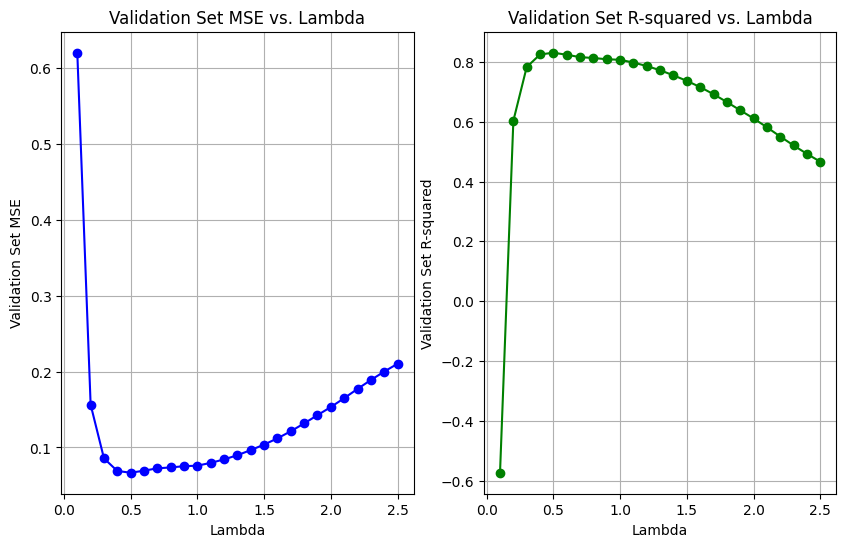

In [9]:
# Plot lambda values vs. validation set metrics
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.plot(lam_values, validation_mse, marker='o', linestyle='-', color='blue')
plt.title('Validation Set MSE vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Validation Set MSE')
plt.grid(True)

plt.subplot(122)
plt.plot(lam_values, validation_r2, marker='o', linestyle='-', color='green')
plt.title('Validation Set R-squared vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Validation Set R-squared')
plt.grid(True)

Based on the previous work, we should have an optimal value for $\lambda$ based on the selected $D(t)$. We now compute that model. 

Notice that we choose to construct that model from a combination of both the training and validation set; however, you can do this with only the training set if you wish. A larger training set for the final model is generally the better choice. 

Mean Squared Error on testing set with best lambda (0.5): 0.0453
R-squared on testing set with best lambda (0.5): 0.9010


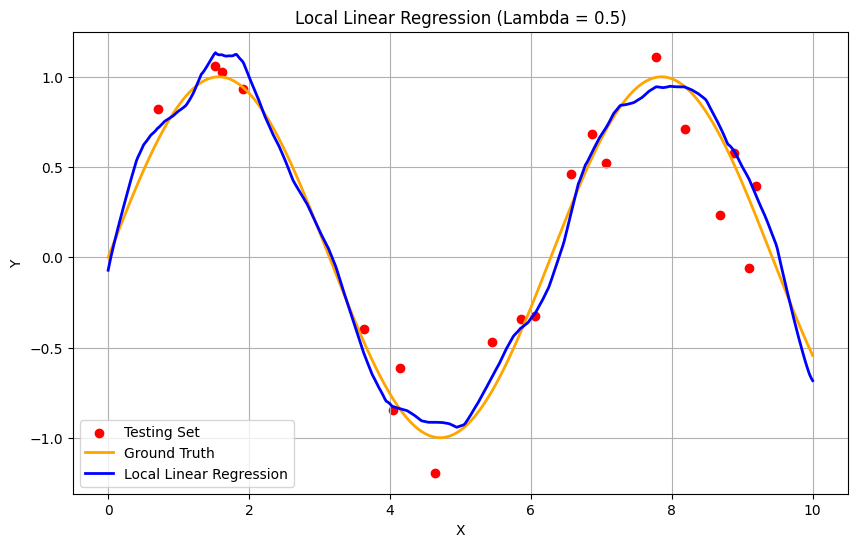

In [10]:
# Iterate through X_range and calculate y_pred using local regression
y_pred_plot = [local_regression(x0, X_train_val, y_train_val, 
                                best_lambda, kernel, D) for x0 in X_range]

# Iterate through X_test and calculate y_pred using local regression
y_pred_test = [local_regression(x0, X_train_val, y_train_val, 
                                best_lambda, kernel, D) for x0 in X_test]

# Calculate MSE and R2 on the testing set
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Mean Squared Error on testing set with best lambda ({best_lambda}): {test_mse:.4f}")
print(f"R-squared on testing set with best lambda ({best_lambda}): {test_r2:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Testing Set')
plt.plot(X_range, y_truth, label=f'Ground Truth', color='orange', linewidth=2)
plt.plot(X_range, y_pred_plot, color='blue', lw=2, label='Local Linear Regression')
plt.title(f'Local Linear Regression (Lambda = {best_lambda})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


Was the model you constructed close to the ground truth? Overall, how did your work come out? 

## Polynomial Fit 

Now let us repeat this process but with a local polynomial regression. As before, we need to select a $\lambda$ and $D(t)$, but now we also need to select the degree of the polynomial. In the example below (which uses the same dataset), we use the validation set to select both $\lambda$ and the degree. 

We do not need to repeat the functions for $K(x_0, x)$ nor $D(t)$, defined above because we will use the same ones. All we need to define is the local polynomial regression, which is very similar to the local linear regression. 

In [11]:
def local_polynomial_regression(x0:float, X:np.ndarray, 
                                y:np.ndarray, deg:int, 
                                lam:float, K:Callable, D:Callable) -> float:
    """
    Computes estimate of y0 using local polynomial regression (degree deg) at point x0 with training sets X and y
    """
    
    # Calculate the weights using the Gaussian kernel
    weights = K(x0, X, lam, D)

    # Fit a local polynomial regression using numpy.polyfit
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=np.RankWarning)  # Suppress RankWarning
        coefficients = np.polyfit(X, y, deg, w=weights)

    # Create a polynomial function from the coefficients
    poly_function = np.poly1d(coefficients)

    # Evaluate the polynomial function on the training data
    y_pred = poly_function(x0)
    
    return y_pred

Here is a space of where one can tinker and visually explore choices of $\lambda$, degree, and $D(t)$. 

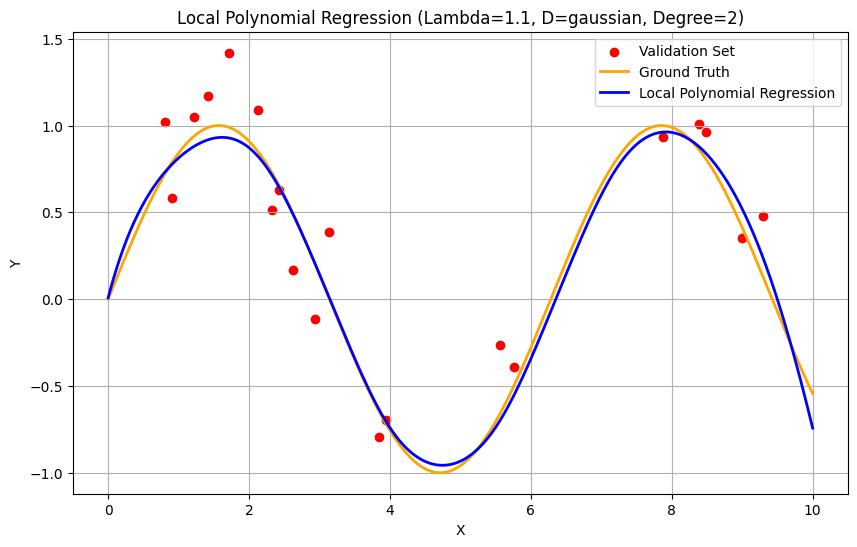

In [12]:
# Tinker with different polynomial degrees, lambda values, and D(t)
deg = 2
lam = 1.1
D = gaussian

# Iterate through X_range and calculate the model using local polynomial regression
y_pred_plot_poly = [local_polynomial_regression(x0, X_train, y_train, 
                                                deg, lam, kernel, D) for x0 in X_range]

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_val, y_val, color='red', label='Validation Set')
plt.plot(X_range, y_truth, label='Ground Truth', color='orange', linewidth=2)
plt.plot(X_range, y_pred_plot_poly, color='blue', lw=2, label='Local Polynomial Regression')
plt.title(f'Local Polynomial Regression (Lambda={lam}, D={D.__name__}, Degree={deg})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

We now attempt to compute the best value of $\lambda$ as a function of degrees. In the next cell, we will cycle through potential degrees, identify the best $\lambda$ for that degree, and calculate the relevant metrics. 

In [13]:
def best_lambda(deg:int, X_train:np.ndarray, 
                y_train:np.ndarray, 
                X_val:np.ndarray, y_val:np.ndarray) -> tuple:
    """
    Computes best lam value for local_polynomial_regression with choice of degree using validation sets X_val and y_val
    """
    
    lam_values = np.arange(0.1, 2.6, 0.2)
    
    validation_mse_poly = []
    validation_r2_poly = []
    
    # Try different values of lambda for local polynomial regression 
    # select the best lambda based on validation set metrics
    for lam in lam_values:
        
        # Predict on the validation set
        y_pred_val_poly = [local_polynomial_regression(x0, X_train, y_train, deg, lam, kernel, D) for x0 in X_val]
        
        # Calculate Mean Squared Error (MSE) on the validation set
        mse_poly = mean_squared_error(y_val, y_pred_val_poly)
        
        # Calculate Coefficient of Determination (R^2) on the validation set
        r2_poly = r2_score(y_val, y_pred_val_poly)
        
        # Append corresponding metrics to lists
        validation_mse_poly.append(mse_poly)
        validation_r2_poly.append(r2_poly)
    
    # Find the best lambda based on validation set mean squared error
    mse_poly = min(validation_mse_poly)
    best_lambda = round(lam_values[np.argmin(validation_mse_poly)], 2)
    r2_poly = round(validation_r2_poly[np.argmin(validation_mse_poly)], 2)
    
    return best_lambda, mse_poly, r2_poly
    

Here, we cycle through possible degree values starting from 2. We generally do not want to go too high in degree--the higher the degree, the more terms in our fit, which increases computational complexity. We then find the optimal value of lambda and lowest MSE for each degree value. Then we calculate the smallest of all the mean squared error values to identify the corresponding degree. 

Note that you may get a convergence error if $D(t)$ is not Gaussian.

In [14]:
degs = list(range(2, 8, 1))
mses_poly = []
lambdas = []
r2s_poly = []

for deg in degs:
    lam, mse, r2 = best_lambda(deg, X_train, y_train, X_val, y_val)
    lambdas.append(lam)
    mses_poly.append(mse)
    r2s_poly.append(r2)

best_deg = round(degs[np.argmin(mses_poly)])
deg_mse = min(mses_poly)
deg_r2 = r2s_poly[np.argmin(mses_poly)]
best_lam = round(lambdas[np.argmin(mses_poly)], 3)

print(f"Best degree based on validation set MSE: {best_deg}")
print(f"Corresponding lambda based on validation set MSE: {best_lam}")

Best degree based on validation set MSE: 3
Corresponding lambda based on validation set MSE: 2.1


Here, we can graph the values found in the previous loop. This is not strictly necessary but can provide some valuable information. For example, the above calculation will find the smallest degree with the lowest MSE. If there is a tie between two different degree values, however, we'd be able to see this in the graphs. 

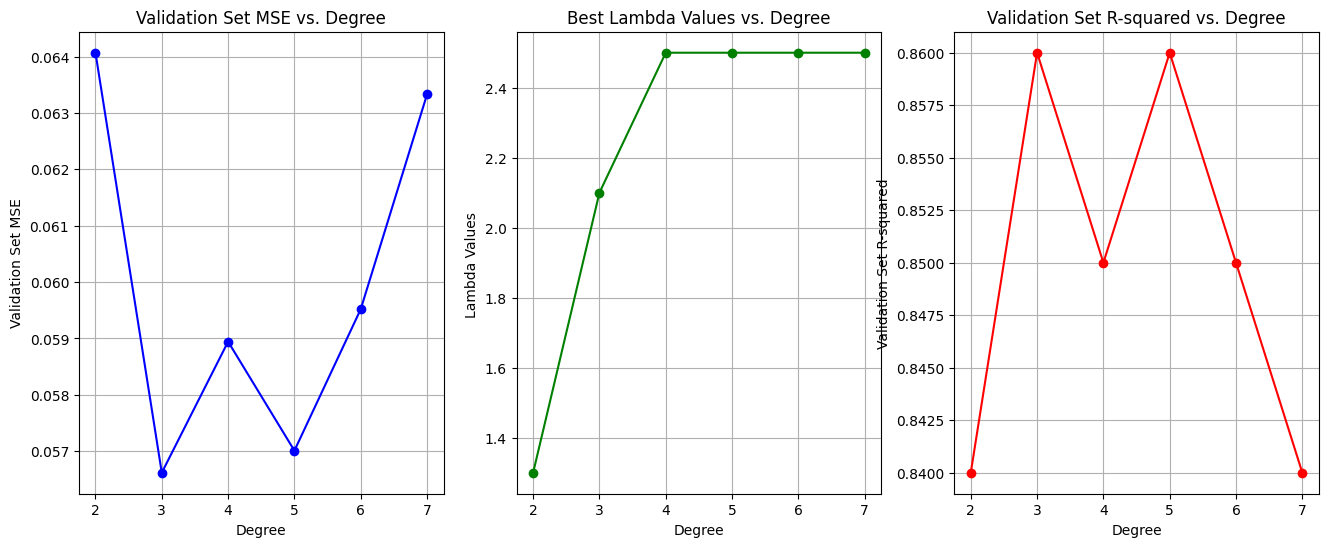

In [15]:
# Plot degree values against validation set metrics and lambda
plt.figure(figsize=(16, 6))
plt.subplot(131)
plt.plot(degs, mses_poly, marker='o', linestyle='-', color='blue')
plt.title('Validation Set MSE vs. Degree')
plt.xlabel('Degree')
plt.ylabel('Validation Set MSE')
plt.grid(True)

plt.subplot(132)
plt.plot(degs, lambdas, marker='o', linestyle='-', color='green')
plt.title('Best Lambda Values vs. Degree')
plt.xlabel('Degree')
plt.ylabel('Lambda Values ')
plt.grid(True)

plt.subplot(133)
plt.plot(degs, r2s_poly, marker='o', linestyle='-', color='red')
plt.title('Validation Set R-squared vs. Degree')
plt.xlabel('Degree')
plt.ylabel('Validation Set R-squared')
plt.grid(True)

We now compute the model with the metrics previously calculated.

Mean Squared Error on testing set with best degree (3) and its lambda value (2.1): 0.0632
R-squared on testing set with best degree (3) and its lambda value (2.1): 0.8619


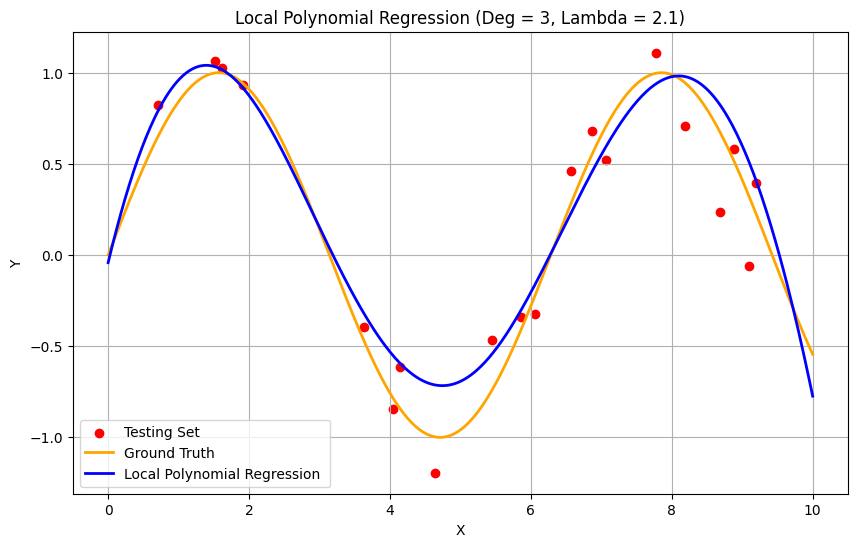

In [16]:
# For graphing the local polynomial regression
# Iterate through X_range and calculate y_pred_plot using local polynomial regression
y_pred_plot = [local_polynomial_regression(x0, X_train_val, 
                                           y_train_val, best_deg, 
                                           best_lam, kernel, D) for x0 in X_range]

# For evaluating the local polynomial regression
# Iterate through X_test and calculate y_pred_test using local regression
y_pred_test = [local_polynomial_regression(x0, X_train_val, 
                                           y_train_val, best_deg, 
                                           best_lam, kernel, D) for x0 in X_test]

# Calculate MSE and R2 on the testing set
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Mean Squared Error on testing set with best degree ({best_deg}) and its lambda value ({best_lam}): {test_mse:.4f}")
print(f"R-squared on testing set with best degree ({best_deg}) and its lambda value ({best_lam}): {test_r2:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Testing Set')
plt.plot(X_range, y_truth, label=f'Ground Truth', color='orange', linewidth=2)
plt.plot(X_range, y_pred_plot, color='blue', lw=2, label='Local Polynomial Regression ')
plt.title(f'Local Polynomial Regression (Deg = {best_deg}, Lambda = {best_lam})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()
